# SemiSim
## Set up Requirements
1. Python (3.8 or 3.9 recommended)
- Installed via Anaconda or plain Python
2. Notebook file: SemiSim_Final.ipynb
3. Environment: semisim_env
- conda env create -f environment.yml
- conda activate semisim_env
4. Dependencies
- Should be included with environment

## Import Libraries

In [132]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
import matplotlib.animation as animation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Input, Concatenate
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from IPython.display import HTML

## Focal Loss
The focal loss function is used to improve classification performance on imbalanced datasets by down-weighting easy examples and focusing the model’s learning on harder, misclassified ones. It introduces a scaling factor controlled by gamma to reduce the impact of well-predicted samples and applies a class-balancing term, alpha, to give more weight to the minority class. This helps the model learn better in situations where one class (like phase-separating proteins) is much less frequent than the other.

In [133]:
def focal_loss(gamma=2., alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = K.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1. - p_t, gamma)
        return -K.mean(alpha_factor * modulating_factor * K.log(p_t))
    return loss_fn

## Dataset
This section loads and prepares the LLPS dataset by removing entries without labels or sequences. It encodes amino acids into integers and calculates sequence-derived features such as length, average hydrophobicity, and residue composition related to charge, disorder, and aromaticity. These features are combined with existing numerical descriptors. Protein sequences are padded for uniform input length, and all features are scaled for model training. Finally, the data is split into training and test sets while preserving the class distribution.

In [134]:
# === Load and preprocess dataset ===
df = pd.read_csv("llpsdb_with_labels.csv")
df_clean = df.dropna(subset=["label", "sequence"])

# === Feature Engineering from Sequence ===
aa_to_int = {aa: i+1 for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY")}
kd_scale = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8, 'G': -0.4, 'H': -3.2,
    'I': 4.5, 'K': -3.9, 'L': 3.8, 'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5,
    'R': -4.5, 'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}

def compute_sequence_features(seq):
    length = len(seq)
    hydrophobicity = np.mean([kd_scale.get(aa, 0) for aa in seq])
    charge_frac = sum(seq.count(x) for x in "DEKR") / length
    disorder_frac = sum(seq.count(x) for x in "GSQP") / length
    aromatic_frac = sum(seq.count(x) for x in "FYW") / length
    return pd.Series([length, hydrophobicity, charge_frac, disorder_frac, aromatic_frac])

extra_feature_df = df_clean['sequence'].apply(compute_sequence_features)
extra_feature_df.columns = ['seq_length', 'avg_hydrophobicity', 'charge_frac', 'disorder_frac', 'aromatic_frac']

# === Extract Tabular + Sequence Inputs ===
non_feature_cols = [
    'Unnamed: 0', 'entry', 'literID', 'PSID', 'protID', 'Protein', 'sequence',
    'Phase_separation', 'label'
]
tabular_cols = [col for col in df_clean.columns if col not in non_feature_cols]
X_tabular = df_clean[tabular_cols].select_dtypes(include='number').fillna(0)
X_extra = extra_feature_df.fillna(0)
y = df_clean['label'].astype(int)

# === Encode Sequences ===
def encode_sequence(seq):
    return [aa_to_int.get(aa, 0) for aa in seq]

sequences = df_clean['sequence'].apply(encode_sequence)
X_seq_int = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

# === Scale all tabular features ===
scaler = StandardScaler()
X_tabular_combined = pd.concat([X_tabular, X_extra], axis=1)
X_tabular_scaled = scaler.fit_transform(X_tabular_combined)

# === Train-test split using same indices ===
X_seq_train, X_seq_test, X_tabular_train, X_tabular_test, y_train, y_test = train_test_split(
    X_seq_int, X_tabular_scaled, y, test_size=0.2, stratify=y, random_state=42
)


## Model Architecture, Training, and Evaluation with Monte Carlo Dropout
This section defines and trains a deep learning model to predict LLPS. It uses an embedding and LSTM layer to process protein sequences and concatenates them with engineered tabular features. The combined features pass through dense layers with dropout for regularization. The model is compiled using the Adam optimizer and focal loss to handle class imbalance, then trained with early stopping. After training, Monte Carlo dropout is used for prediction uncertainty. Model performance is evaluated using ROC metrics, Youden’s J statistic to select the best threshold, and a classification report with AUC visualization.

Epoch 1/100
9/9 [==============================] - 4s 101ms/step - loss: 0.1868 - accuracy: 0.6464 - val_loss: 0.1370 - val_accuracy: 0.7000
Epoch 2/100
9/9 [==============================] - 0s 35ms/step - loss: 0.1467 - accuracy: 0.6750 - val_loss: 0.1184 - val_accuracy: 0.7000
Epoch 3/100
9/9 [==============================] - 0s 33ms/step - loss: 0.1477 - accuracy: 0.6750 - val_loss: 0.1188 - val_accuracy: 0.7000
Epoch 4/100
9/9 [==============================] - 0s 33ms/step - loss: 0.1426 - accuracy: 0.6750 - val_loss: 0.1157 - val_accuracy: 0.7000
Epoch 5/100
9/9 [==============================] - 0s 35ms/step - loss: 0.1416 - accuracy: 0.6750 - val_loss: 0.1131 - val_accuracy: 0.7000
Epoch 6/100
9/9 [==============================] - 0s 36ms/step - loss: 0.1435 - accuracy: 0.6750 - val_loss: 0.1120 - val_accuracy: 0.7000
Epoch 7/100
9/9 [==============================] - 0s 32ms/step - loss: 0.1389 - accuracy: 0.6750 - val_loss: 0.1114 - val_accuracy: 0.7000
Epoch 8/100
9/9 [==

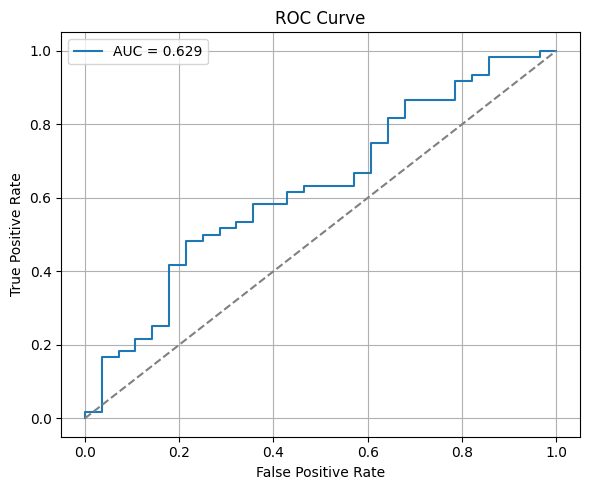

In [140]:
# === Model Architecture ===
seq_input = Input(shape=(X_seq_int.shape[1],), name='seq_input')
embed = Embedding(input_dim=len(aa_to_int) + 1, output_dim=32)(seq_input)
lstm = LSTM(64)(embed)

feat_input = Input(shape=(X_tabular_scaled.shape[1],), name='feat_input')
combined = Concatenate()([lstm, feat_input])

x = Dense(64, activation='relu')(combined)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid')(x)

model = Model(inputs=[seq_input, feat_input], outputs=out)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=focal_loss(gamma=1.0, alpha=0.75),
              metrics=['accuracy'])

# === Train the Model ===
class_weight = {0: 1.5, 1: 1.0}
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(
    [X_seq_train, X_tabular_train], y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop]
)

# === Monte Carlo Inference ===
def predict_mc(model, X_inputs, n_iter=50):
    preds = np.array([
        model(X_inputs, training=True).numpy().flatten()
        for _ in range(n_iter)
    ])
    return preds.mean(axis=0), preds.std(axis=0)

y_mc_mean, y_mc_std = predict_mc(model, [X_seq_test, X_tabular_test])
y_mc_pred = (y_mc_mean > 0.5).astype(int)

fpr, tpr, thresholds = roc_curve(y_test, y_mc_mean)
j_scores = tpr - fpr
best_thresh = thresholds[np.argmax(j_scores)]

print(f"\nBest threshold by Youden's J: {best_thresh:.3f}")
y_best = (y_mc_mean > best_thresh).astype(int)
print("\nClassification report at best threshold:")
print(classification_report(y_test, y_best, digits=3))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_mc_mean):.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Explanation of outputs
These training logs and evaluation metrics show how the model's performance evolved over 17 epochs. The training accuracy quickly plateaued around 67.5%, and the validation accuracy remained constant at 70%, indicating that the model did not overfit but also may not have learned more beyond a certain point. The loss decreased initially but then stabilized, aligning with early stopping behavior.

The classification report reveals that the model predicts LLPS-positive proteins (label 1) with high precision (82.4%) but relatively low recall (46.7%), meaning it's better at being correct when it does predict LLPS, but it misses many actual positives. For LLPS-negative proteins (label 0), the recall is high (78.6%), but precision is low (40.7%), meaning it captures most non-separating cases but mislabels many positives as negatives. 

The overall accuracy is 56.8%, and the area under the ROC curve (AUC) is 0.629, suggesting the model performs moderately better than random but leaves room for improvement in both discrimination and generalization.

The dataset likely contributes significantly to these observed training and evaluation patterns. Improving the dataset—by adding more high-quality, diverse examples and ensuring balanced classes—would likely enhance both generalization and discrimination performance. 

## Save Model and Scalar

In [141]:
#Save Model
model.save("SemiSim.keras")

In [142]:
#Save Scaler
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Visual Expectation

In [138]:
# Constants
num_particles = 100
box_size = 10
steps = 100
np.random.seed(42)

# Initialize positions
positions_phase = np.random.normal(loc=5, scale=1.0, size=(num_particles, 2))
positions_non = np.random.uniform(low=0, high=box_size, size=(num_particles, 2))
velocities_phase = (np.random.rand(num_particles, 2) - 0.5) * 0.1
velocities_non = (np.random.rand(num_particles, 2) - 0.5) * 0.1

# Update functions
def update_positions(pos, vel):
    pos += vel
    return np.clip(pos, 0, box_size)

def attract_to_center(pos, strength=0.05):
    center = np.mean(pos, axis=0)
    direction = center - pos
    pos += direction * strength
    return pos

# Set up figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='black')
scat1 = ax1.scatter([], [], s=80, c='cyan', edgecolors='white', linewidths=1)
scat2 = ax2.scatter([], [], s=80, c='magenta', edgecolors='white', linewidths=1)

for ax, title in zip((ax1, ax2), ("Phase-Separating", "Non-Separating")):
    ax.set_xlim(0, box_size)
    ax.set_ylim(0, box_size)
    ax.set_title(title, color='white', fontsize=14)
    ax.set_facecolor('black')
    ax.tick_params(colors='white', labelsize=10)

# Animation logic
def animate(frame):
    global positions_phase, positions_non
    positions_phase = update_positions(positions_phase, velocities_phase)
    positions_non = update_positions(positions_non, velocities_non)
    positions_phase = attract_to_center(positions_phase)
    scat1.set_offsets(positions_phase)
    scat2.set_offsets(positions_non)
    return scat1, scat2

ani = animation.FuncAnimation(fig, animate, frames=steps, interval=50, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())


# Example

In [139]:
# === Load model and scaler ===
loaded_model = load_model("SemiSim.keras", compile=False)
scaler = joblib.load("scaler.pkl")

# === Load and prepare dataset ===
df_clean = df_clean.dropna(subset=["sequence", "label"])

# === Select a phase-separating protein by name ===
protein_name = "Tau"  # Change this to any valid name from df_clean['Protein']
row = df_clean[df_clean['Protein'] == protein_name].iloc[0]
seq_str = row['sequence']

# === Encode sequence ===
aa_to_int = {aa: i+1 for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY")}
encoded_seq = [aa_to_int.get(aa, 0) for aa in seq_str]
X_seq_new = pad_sequences([encoded_seq], maxlen=100, padding='post', truncating='post')

# === Compute extra sequence features ===
def compute_sequence_features(seq):
    kd_scale = {
        'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8, 'G': -0.4, 'H': -3.2,
        'I': 4.5, 'K': -3.9, 'L': 3.8, 'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5,
        'R': -4.5, 'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
    }
    length = len(seq)
    hydrophobicity = np.mean([kd_scale.get(aa, 0) for aa in seq])
    charge_frac = sum(seq.count(x) for x in "DEKR") / length
    disorder_frac = sum(seq.count(x) for x in "GSQP") / length
    aromatic_frac = sum(seq.count(x) for x in "FYW") / length
    return np.array([length, hydrophobicity, charge_frac, disorder_frac, aromatic_frac])

# === Tabular input ===
original_tabular_cols = X_tabular.columns
index = row.name
tabular_values = df_clean.iloc[index][original_tabular_cols].values.astype(float)
extra_values = compute_sequence_features(seq_str).astype(float)
tabular_combined = np.concatenate([tabular_values, extra_values]).reshape(1, -1)
tabular_combined = np.nan_to_num(tabular_combined, nan=0.0, posinf=0.0, neginf=0.0)
X_tabular_new = scaler.transform(tabular_combined)

# === Monte Carlo prediction ===
def monte_carlo_predict(model, X_inputs, n_iter=50):
    preds = np.array([
        model(X_inputs, training=True).numpy().flatten()
        for _ in range(n_iter)
    ])
    return preds.mean(axis=0), preds.std(axis=0)

mean_prob, std_prob = monte_carlo_predict(loaded_model, [X_seq_new, X_tabular_new])
phase_separating = mean_prob[0] > 0.5
label = "Phase-Separating" if phase_separating else "Non-Separating"

print(f"\nProtein name: {protein_name}")
print(f"Predicted LLPS probability: {mean_prob[0]:.3f} ± {std_prob[0]:.3f}")
print(f"Predicted label: {label}")

# === LLPS Simulation with Enhanced Contrast ===
num_particles = 100
box_size = 10
steps = 100
positions = np.random.rand(num_particles, 2) * box_size
velocities = (np.random.rand(num_particles, 2) - 0.5) * 0.5

def update_positions(pos, vel):
    pos += vel
    pos = np.clip(pos, 0, box_size)
    return pos

def attract_to_center(pos, strength=0.08):
    center = np.mean(pos, axis=0)
    direction = center - pos
    pos += direction * strength
    return pos

fig, ax = plt.subplots(figsize=(6, 6))
point_color = 'cyan' if phase_separating else 'magenta'
scat = ax.scatter(
    positions[:, 0], positions[:, 1],
    s=50, c=point_color,
    edgecolors='white', linewidths=0.5
)
ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_facecolor('black')
ax.set_title(f"LLPS Simulation ({label})", color='white')
ax.tick_params(colors='white')
fig.patch.set_facecolor('black')

def animate(frame):
    global positions
    positions = update_positions(positions, velocities)
    if phase_separating:
        positions = attract_to_center(positions)
    scat.set_offsets(positions)
    return scat,

ani = animation.FuncAnimation(fig, animate, frames=steps, interval=50, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())

c:\Users\moria\anaconda3\envs\semisim_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Protein name: Tau
Predicted LLPS probability: 0.694 ± 0.047
Predicted label: Phase-Separating
